In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import janitor
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
num = pd.read_pickle('../02_datos/03_Entrenamiento/num_resultado_calidad.pkl')
cat = pd.read_pickle('../02_datos/03_Entrenamiento/cat_resultado_calidad.pkl')

In [3]:
cat.columns.to_list()

['store_id',
 'item_id',
 'd',
 'year',
 'month',
 'wday',
 'weekday',
 'event_name_1',
 'event_type_1']

In [4]:
incluir = cat.columns.to_list()
del incluir[2]

In [13]:
def frecuencias_cat(df_cat):
    # Asegurarse de pasar las columnas a str
    df_cat = df_cat.astype(str)

    resultado = df_cat.apply(lambda x: x.value_counts(normalize = True)) \
                        .T.stack().dropna() \
                        .to_frame().reset_index() \
                        .rename(columns={'level_0': 'Variable', 'level_1': 'Valor', 0: 'Frecuencia'}) \
                        .sort_values(by=['Variable', 'Frecuencia'])
    return resultado

In [12]:
cat.isna().sum()


store_id        0
item_id         0
d               0
year            0
month           0
wday            0
weekday         0
event_name_1    0
event_type_1    0
dtype: int64

In [14]:
pd.set_option('display.max_rows', None)

frecuencias_cat(cat[incluir])

,Variable,Valor,Frecuencia
41,event_name_1,Chanukah End,0.002
42,event_name_1,Christmas,0.002
43,event_name_1,Cinco De Mayo,0.002
48,event_name_1,Father's day,0.002
61,event_name_1,OrthodoxEaster,0.002
44,event_name_1,ColumbusDay,0.003
45,event_name_1,Easter,0.003
46,event_name_1,Eid al-Fitr,0.003
47,event_name_1,EidAlAdha,0.003
49,event_name_1,Halloween,0.003


In [15]:
pd.set_option('display.max_rows', 6)

In [20]:
def graficos_eda_categoricas(cat):

    #Calculamos el número de filas de necesitamos
    from math import ceil
    filas = ceil(cat.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows=filas, ncols=2, figsize=(16, filas * 6))

    #Aplanamos para iterar el gráfico como si fuera de 1 dimension en lugar de 2
    ax = ax.flat

    #Creamos el bucle que va añadiendo el gráfico
    for cada, variable in enumerate(cat):
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = 'bold')
        ax[cada].tick_params(labelsize = 12)


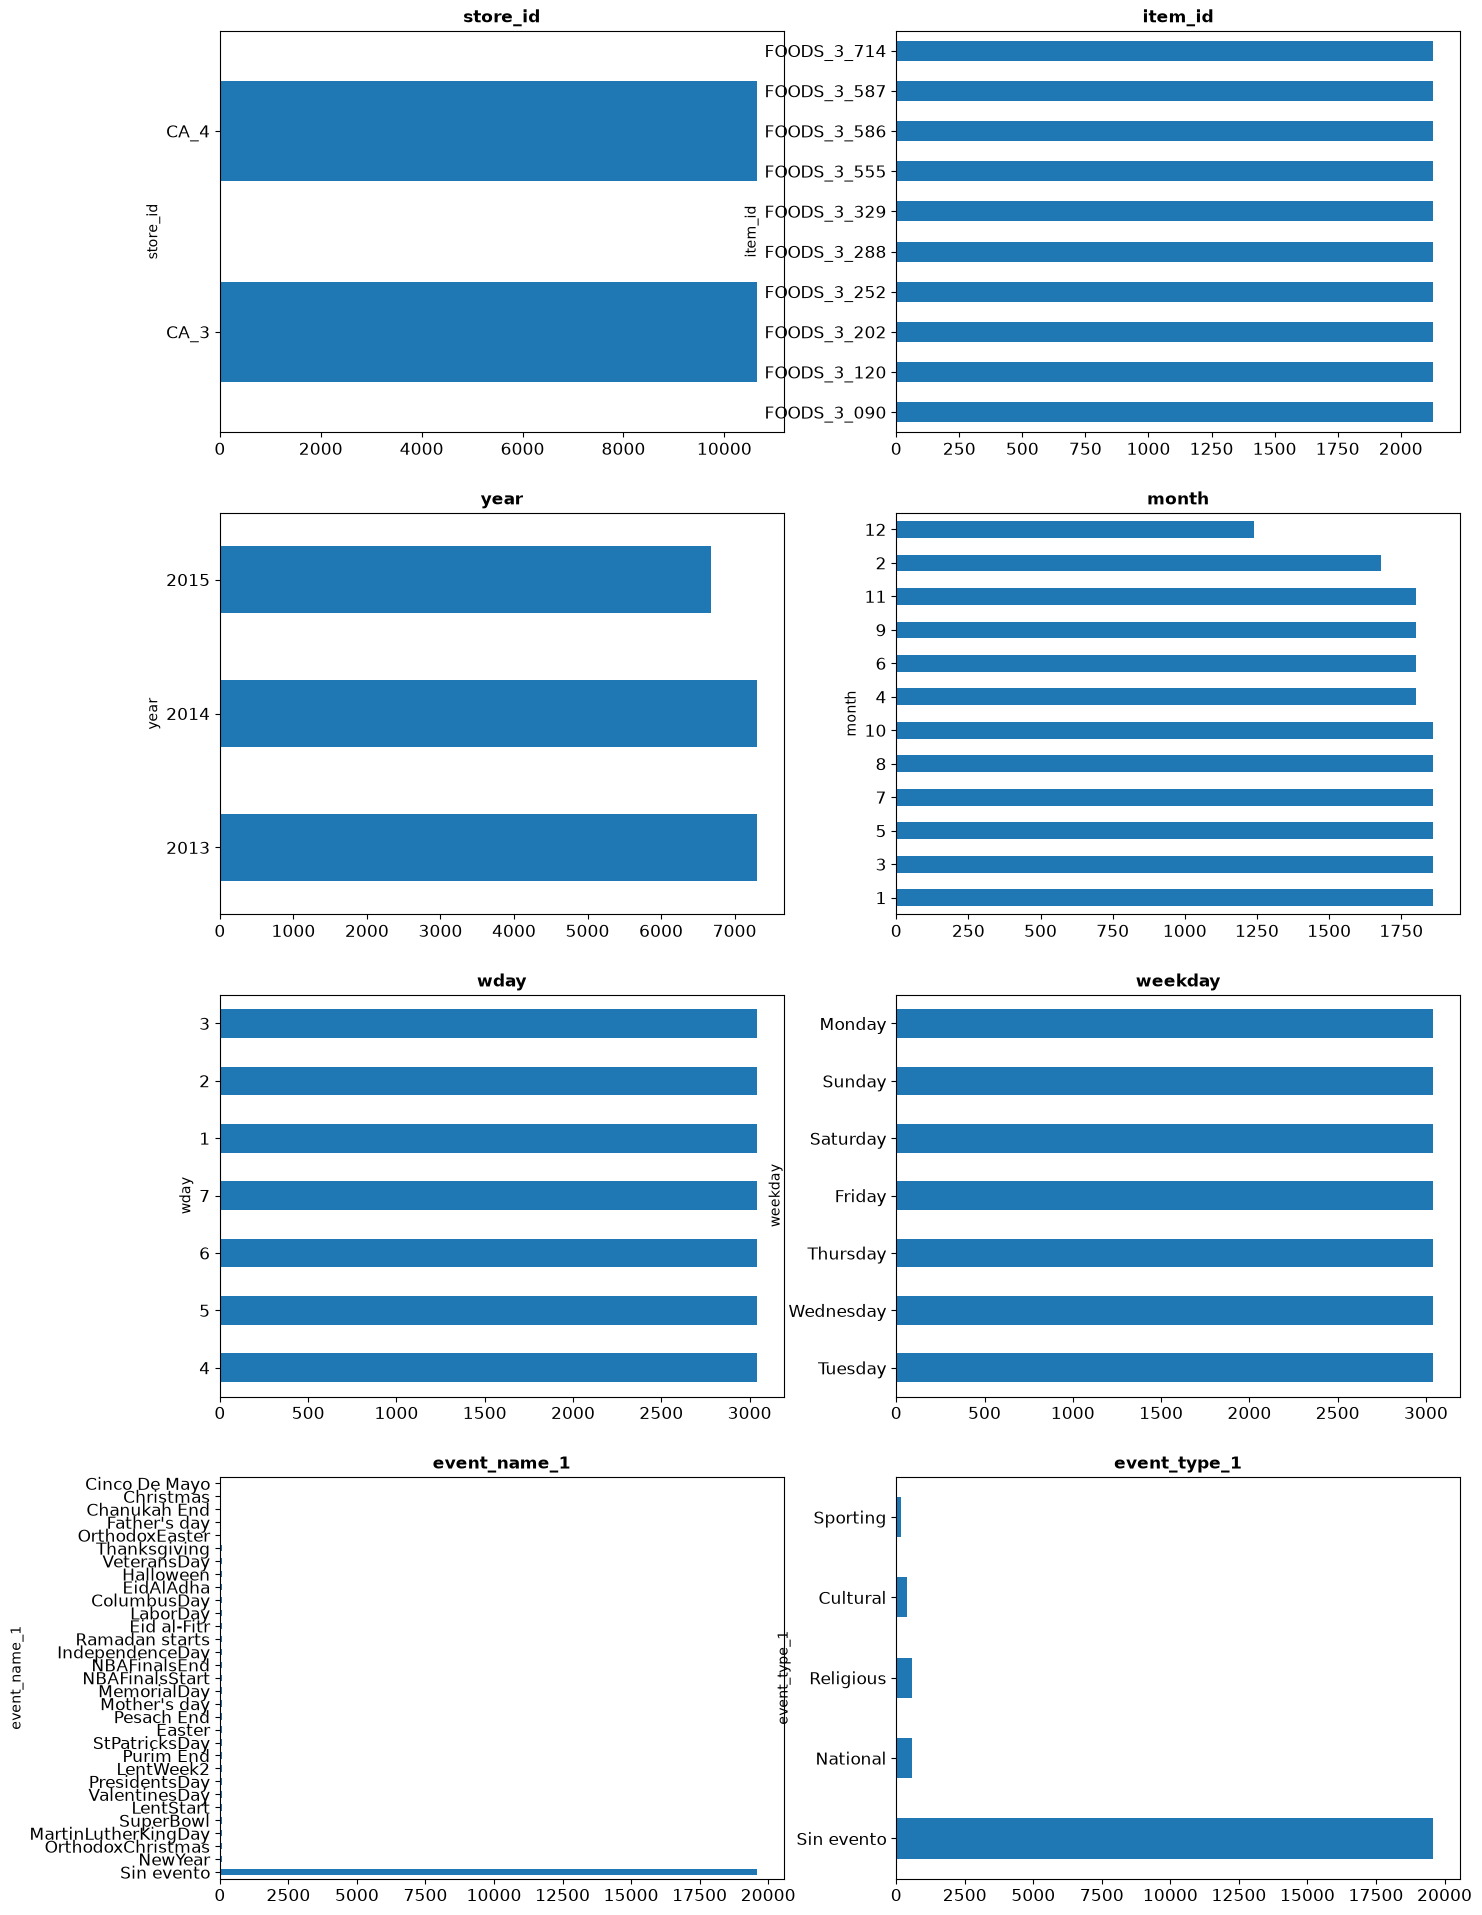

In [21]:
graficos_eda_categoricas(cat[incluir])

In [22]:
def estadisticos_cont(num):
    #Calculamos el describe
    estadisticos = num.describe().T
    #Añadimos la mediana
    estadisticos['median'] = num.median()
    #Reordemaos para que la mediana este al lado de la media
    estadisticos = estadisticos.iloc[:, [0,1,8,2,3,4,5,6,7]]

    #Lo devolvemos
    return (estadisticos)

In [23]:
estadisticos_cont(num)

,count,mean,median,std,min,25%,50%,75%,max
ventas,21280.000,28.875,18.000,38.988,0.000,6.000,18.000,37.000,763.000
sell_price,21280.000,2.394,1.580,1.236,1.000,1.500,1.580,2.980,4.980
wm_yr_wk,21280.000,11415.023,11420.000,82.875,11249.000,11335.000,11420.000,11506.000,11544.000


# Análisis gráfico

In [24]:
df = pd.concat([num,cat], axis=1)

df.head()

,ventas,sell_price,wm_yr_wk,store_id,item_id,d,year,month,wday,weekday,event_name_1,event_type_1
date,,,,,,,,,,,,
2013-01-01,0,1.250,11249,CA_3,FOODS_3_090,d_704,2013,1,4,Tuesday,NewYear,National
2013-01-01,33,1.250,11249,CA_3,FOODS_3_120,d_704,2013,1,4,Tuesday,NewYear,National
2013-01-01,0,4.980,11249,CA_3,FOODS_3_202,d_704,2013,1,4,Tuesday,NewYear,National
2013-01-01,0,4.980,11249,CA_3,FOODS_3_252,d_704,2013,1,4,Tuesday,NewYear,National
2013-01-01,20,4.280,11249,CA_3,FOODS_3_288,d_704,2013,1,4,Tuesday,NewYear,National


# Tendencia global de las ventas

<Axes: xlabel='date'>

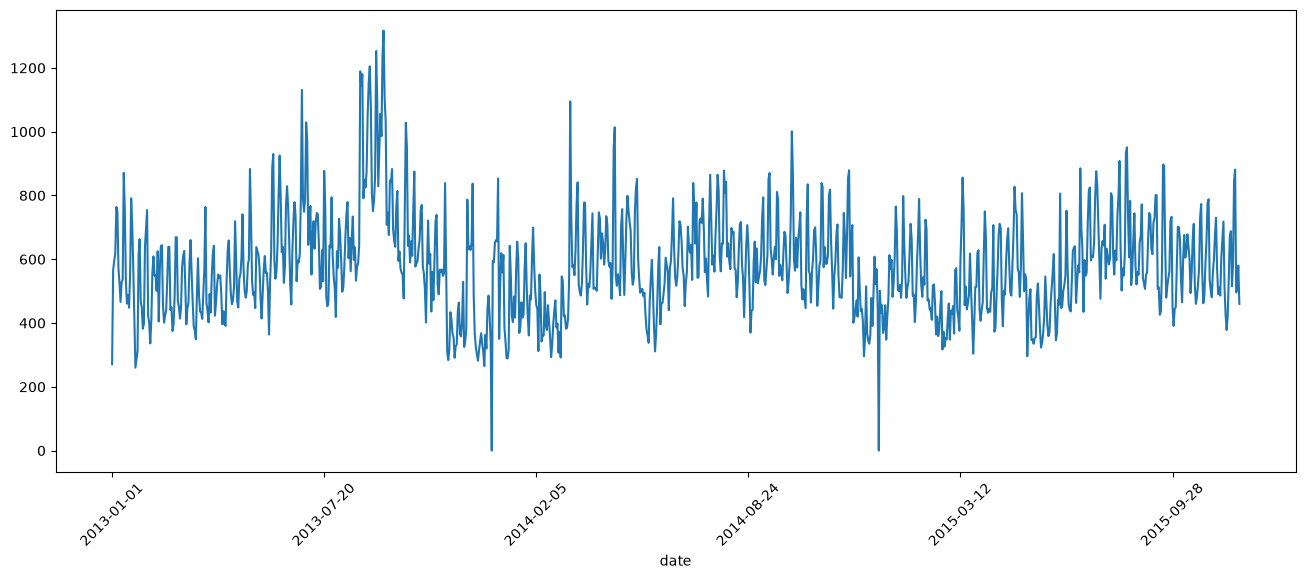

In [25]:
df.groupby('date').ventas.sum().plot(figsize=(16,6), rot=45)

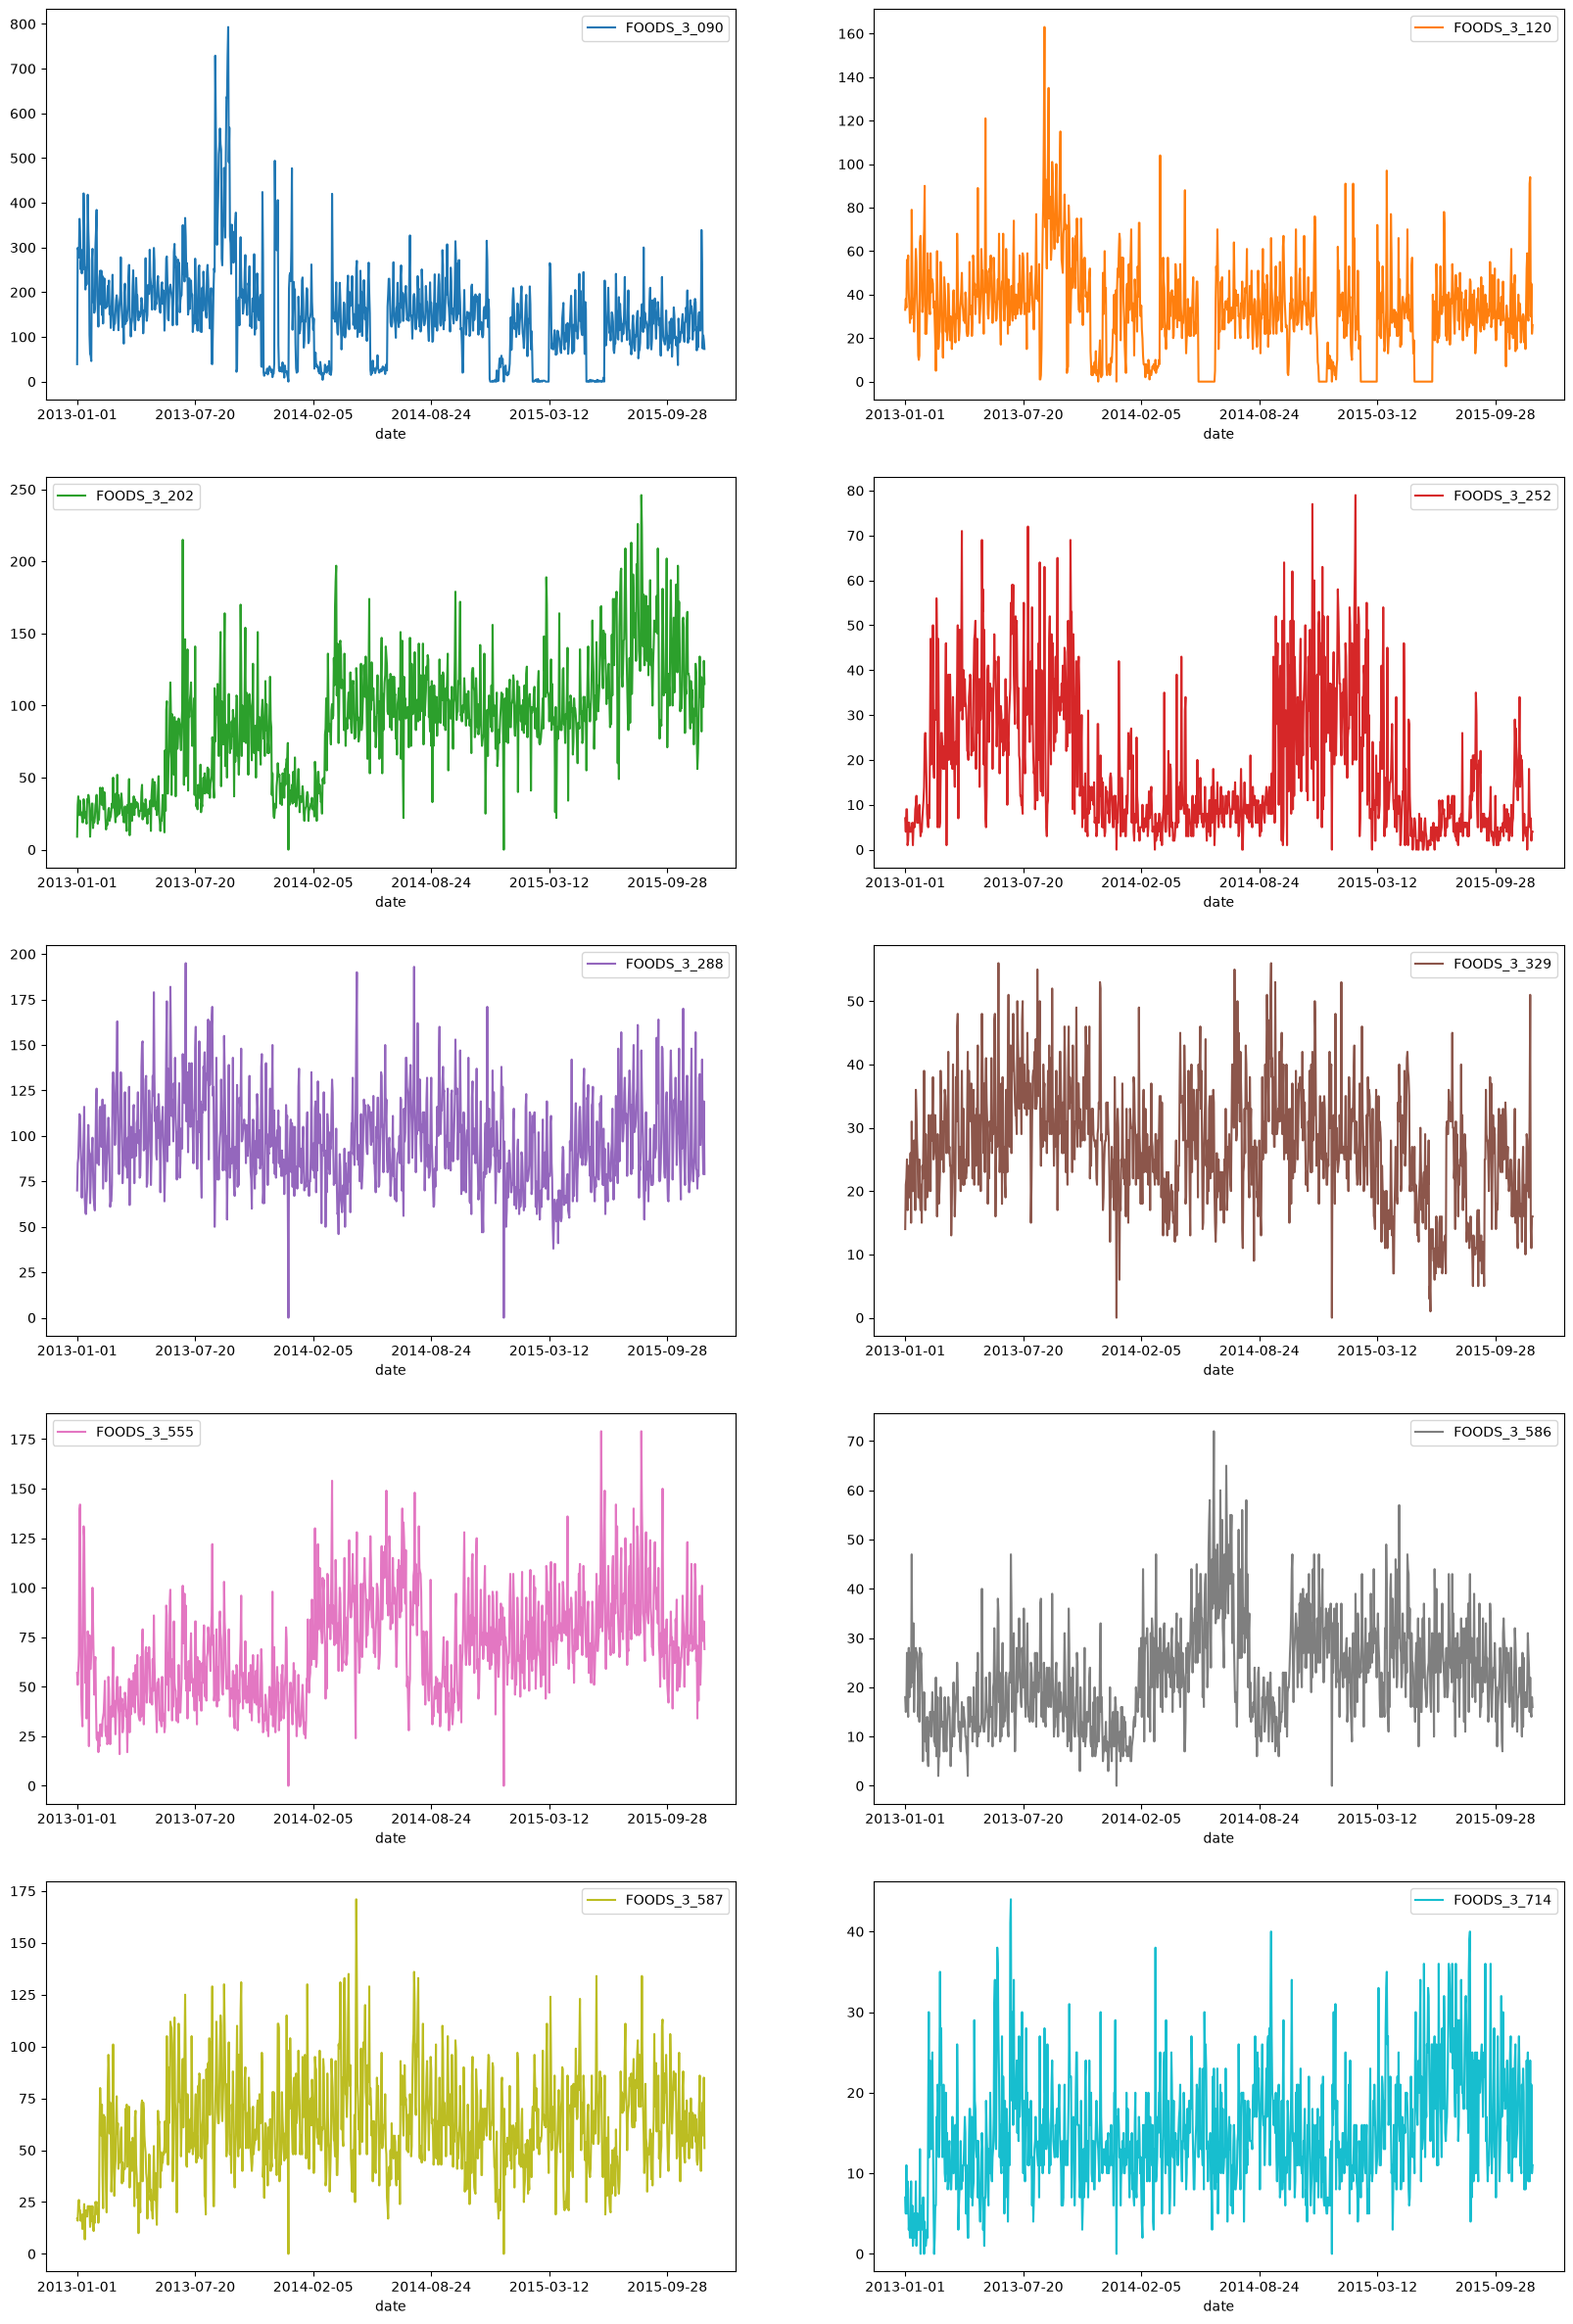

In [27]:
df.groupby(['date', 'item_id']).ventas.sum().unstack().plot(subplots = True, layout = (5, 2), sharex = False, figsize = (20 ,30));

# Análisis gráfico a nivel de tienda y producto

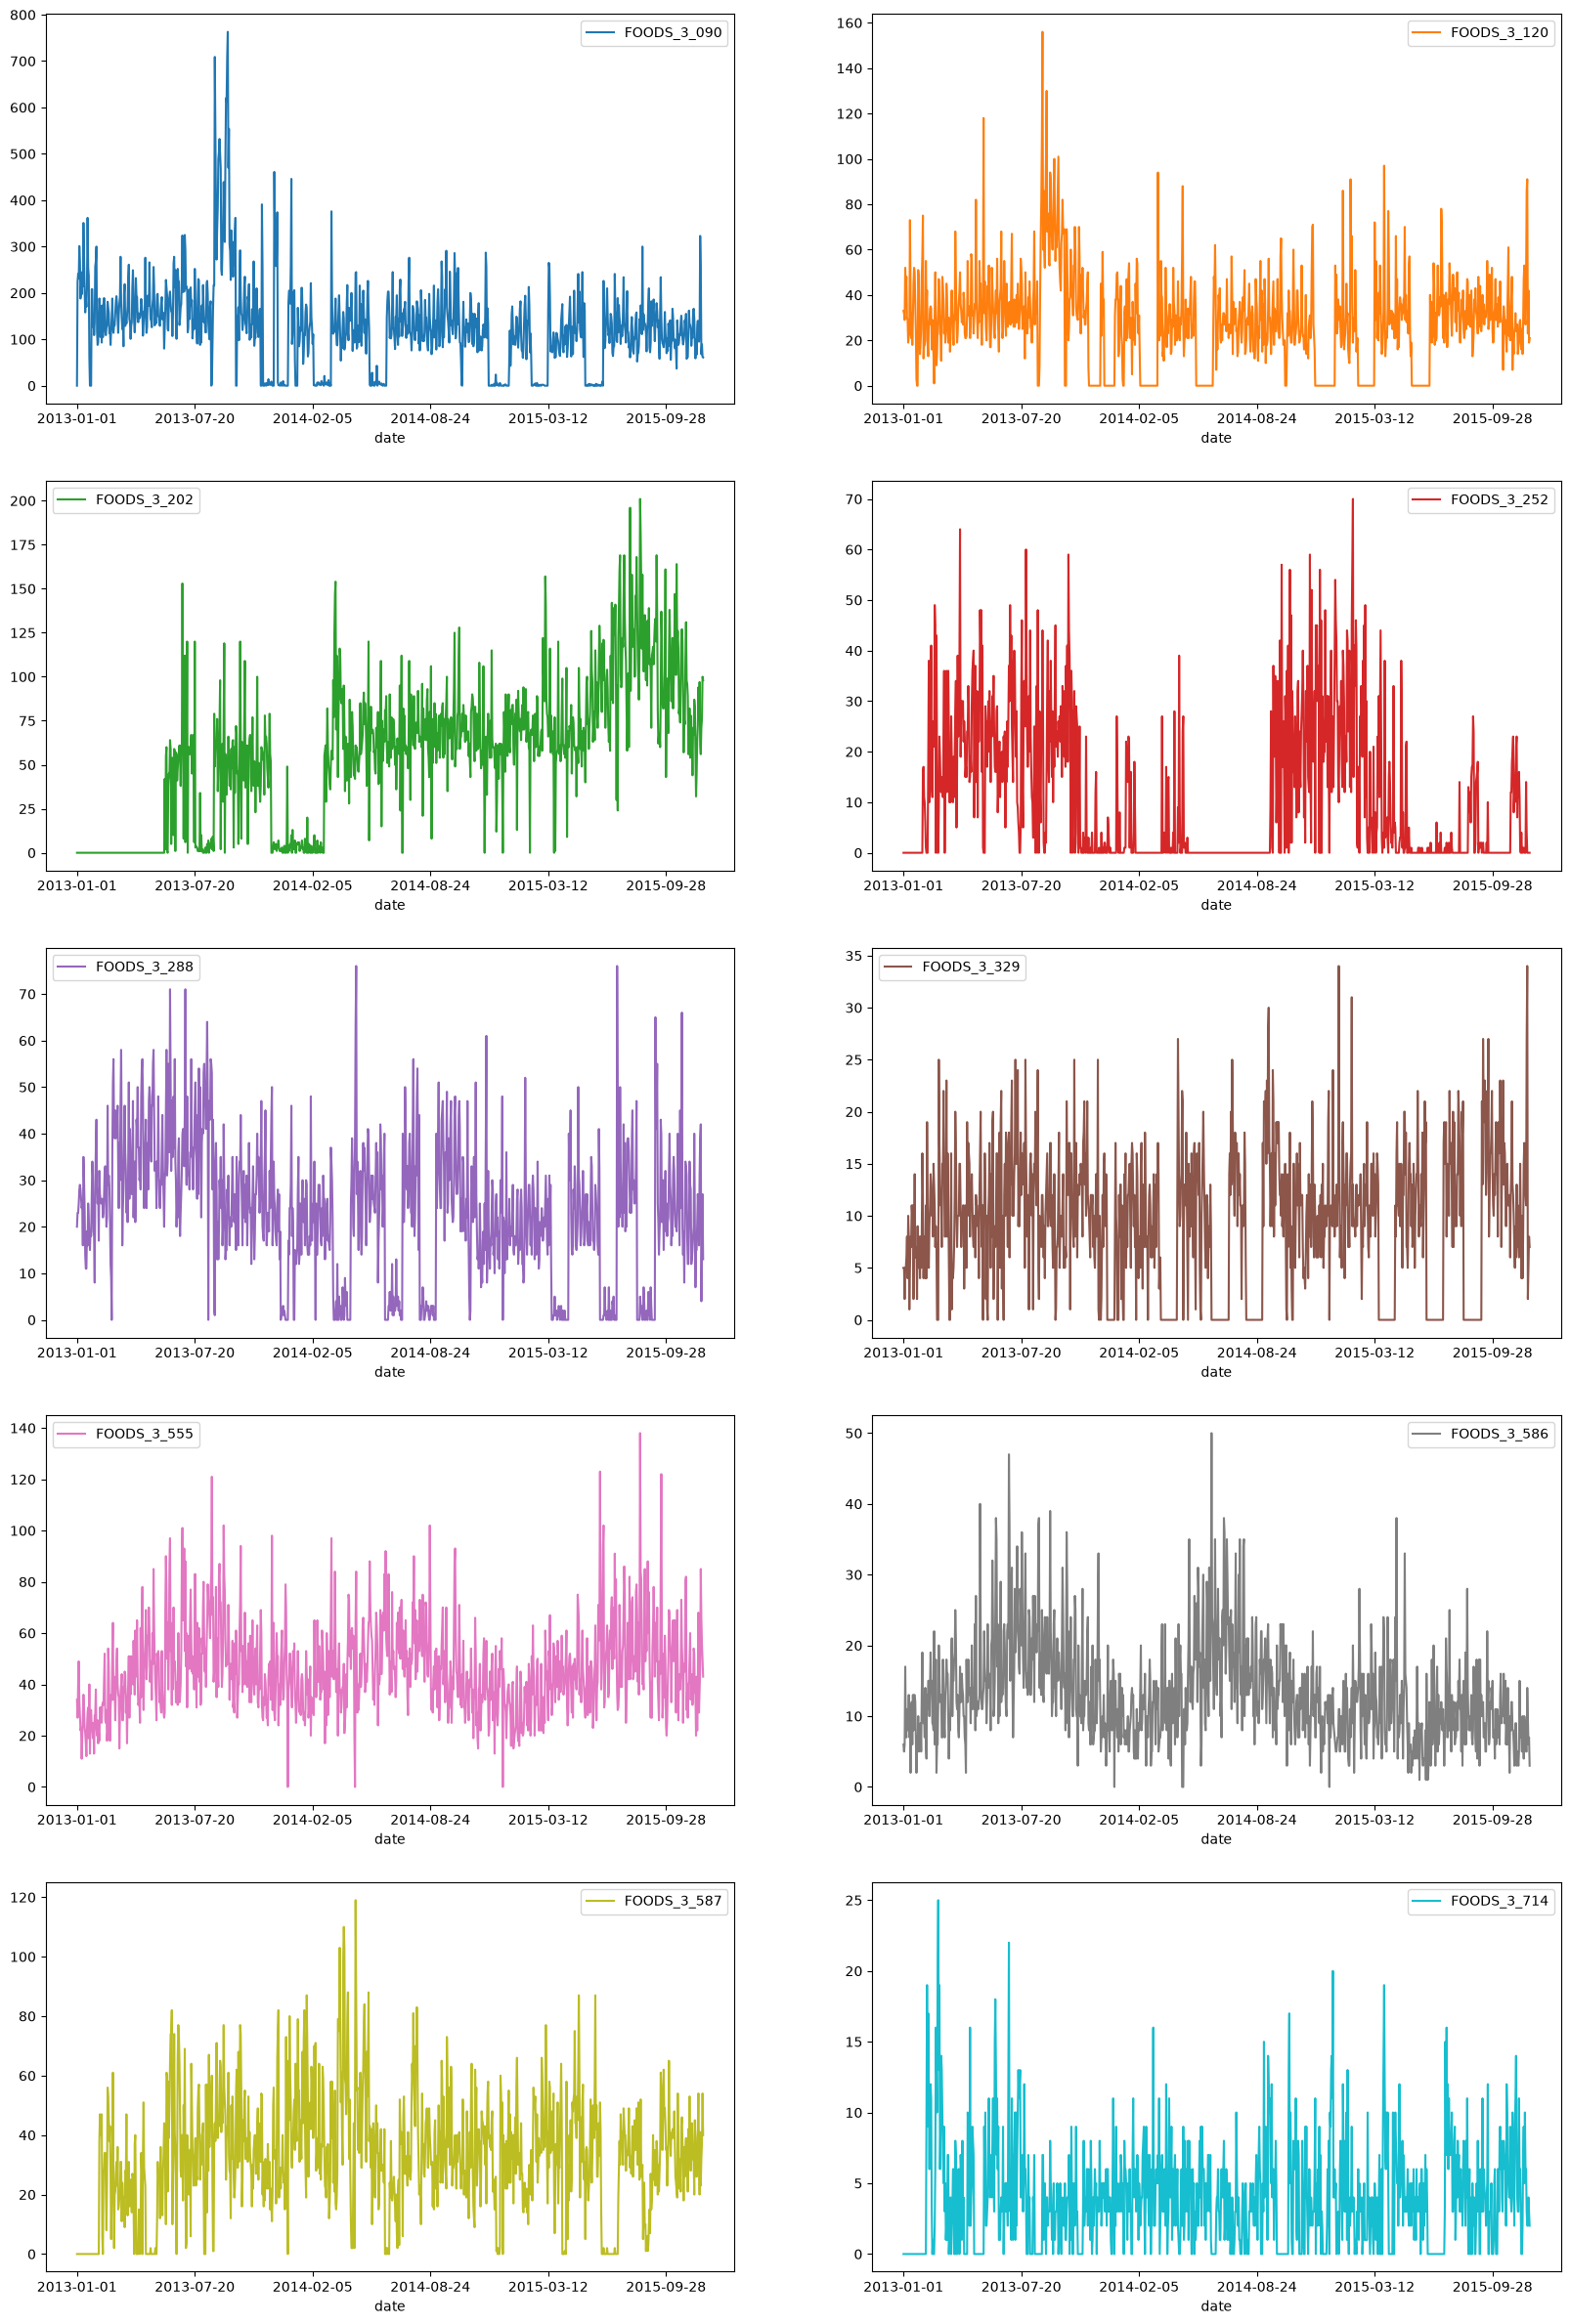

In [32]:
df.loc[df.store_id == 'CA_3'].groupby(['date', 'item_id']).ventas.sum().unstack().plot(subplots = True, layout = (5, 2), sharex = False, figsize = (20 ,30));

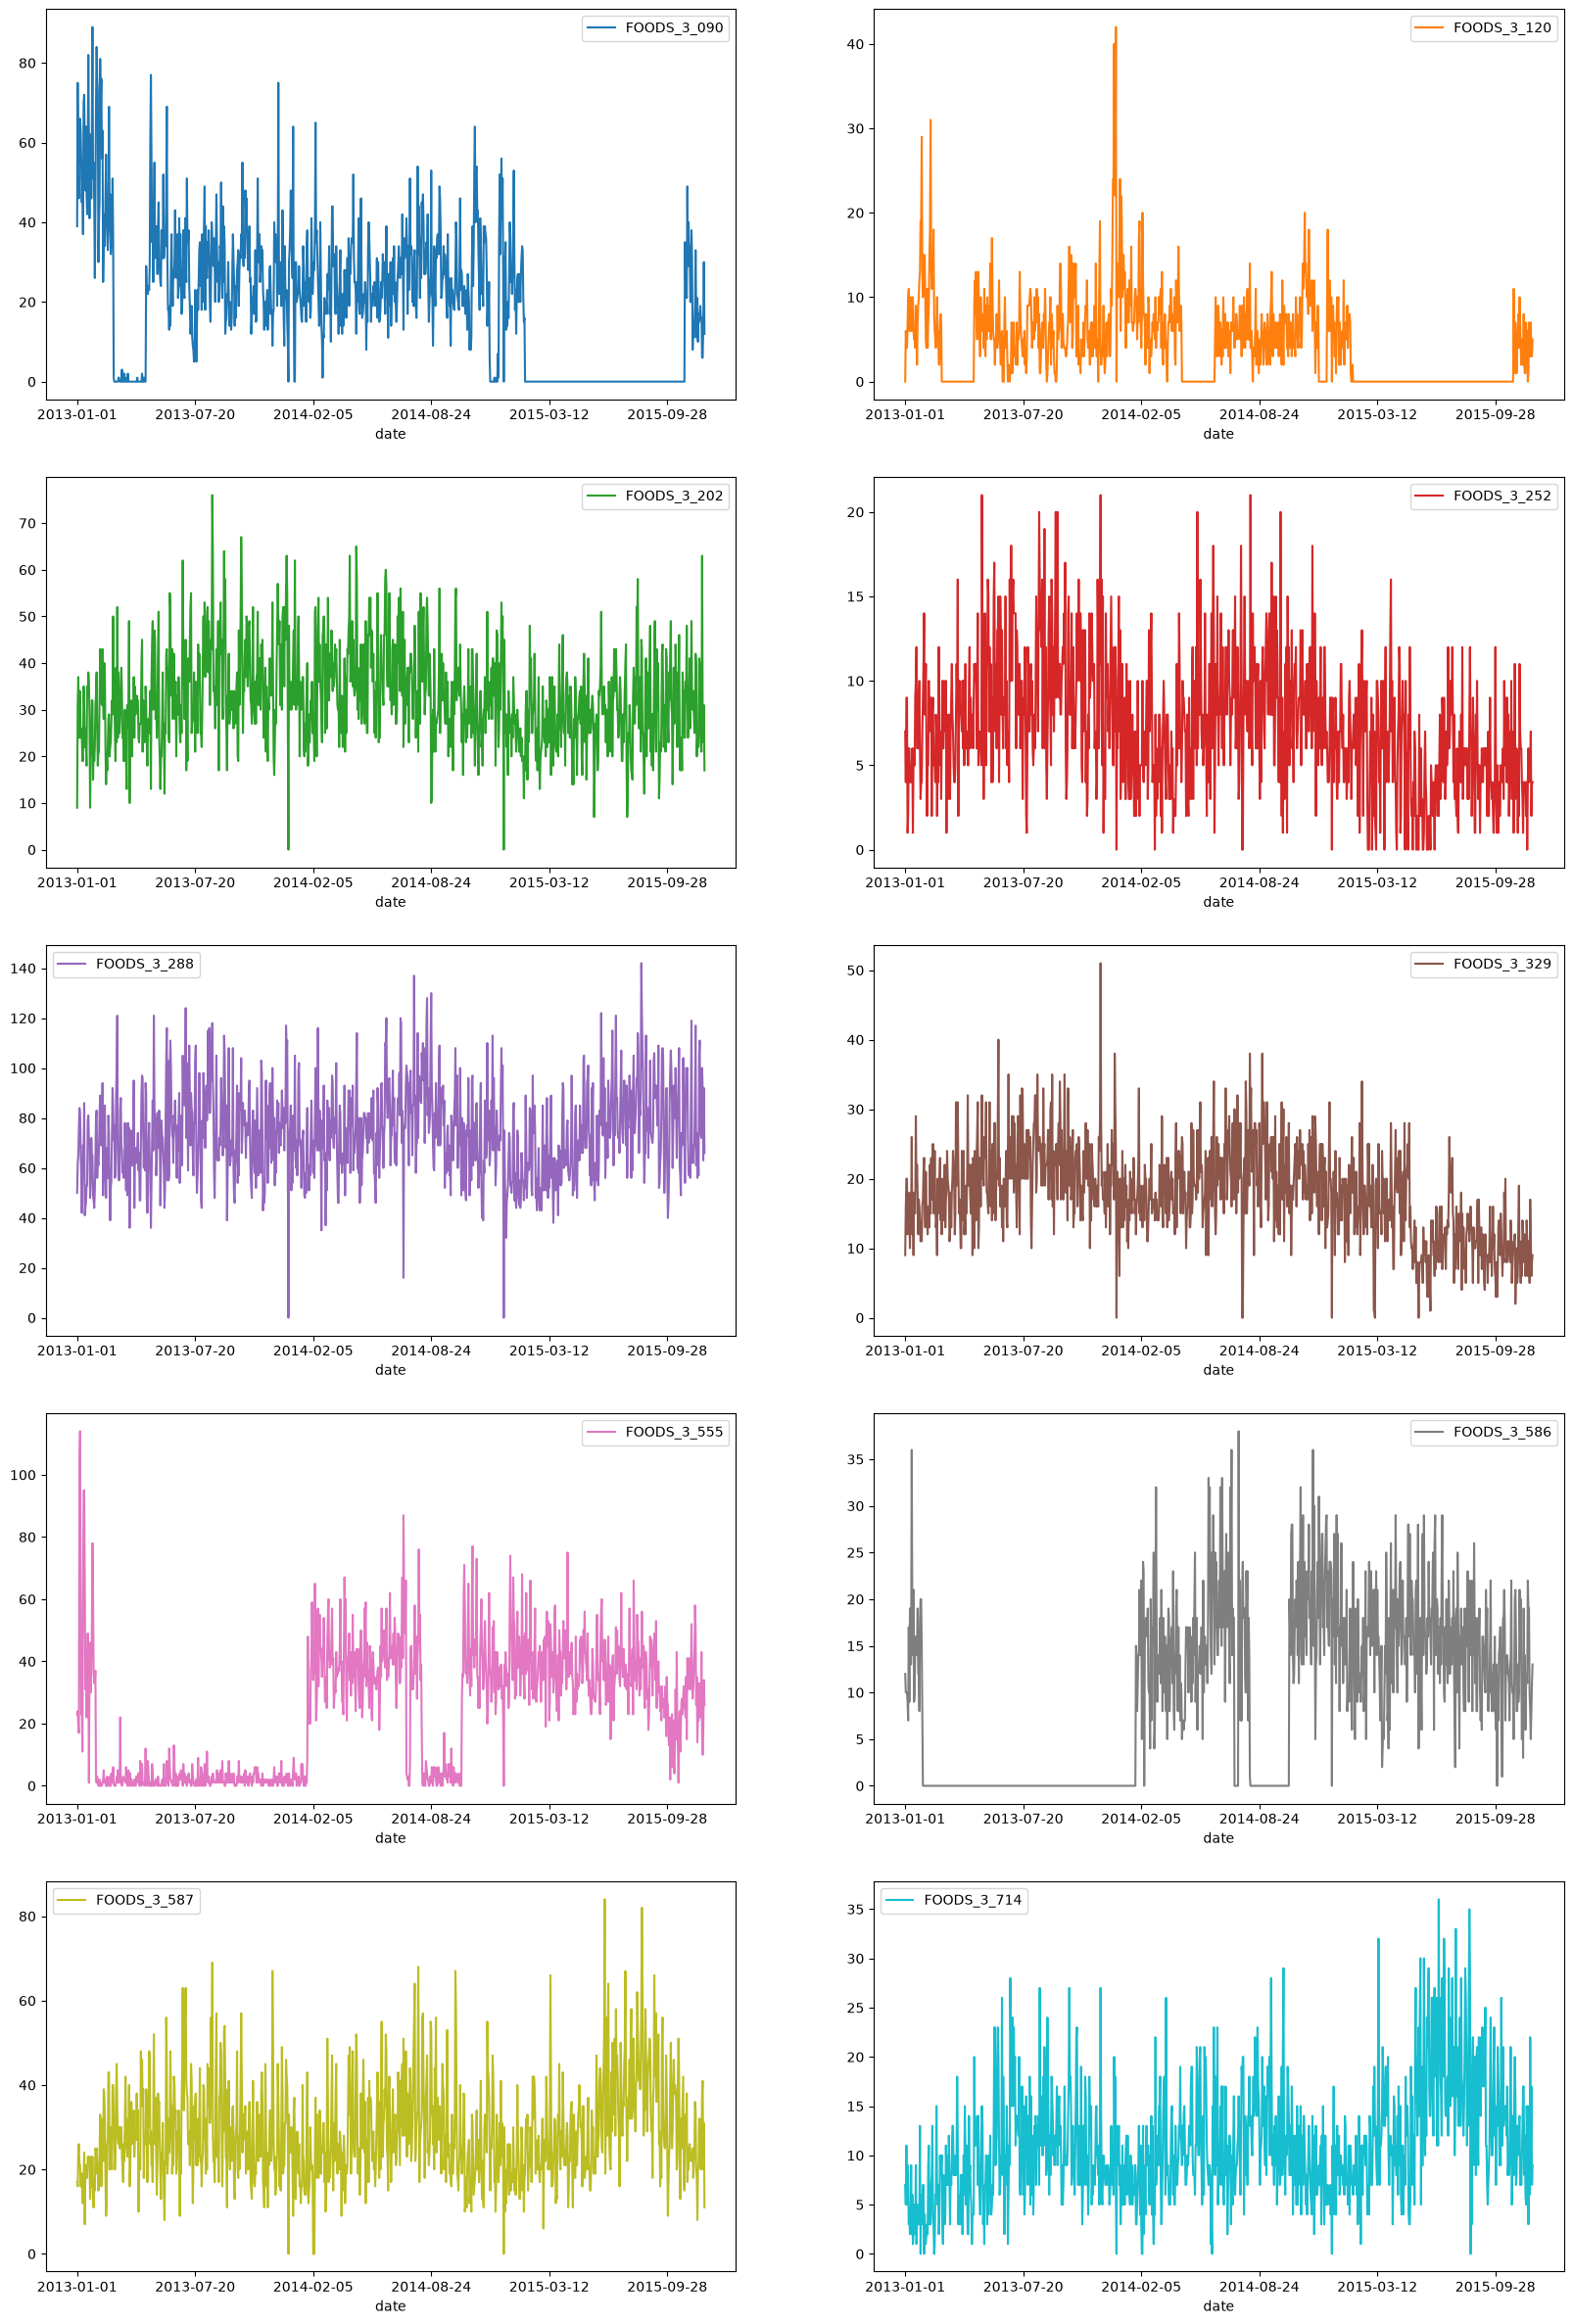

In [33]:
df.loc[df.store_id == 'CA_4'].groupby(['date', 'item_id']).ventas.sum().unstack().plot(subplots = True, layout = (5, 2), sharex = False, figsize = (20 ,30));

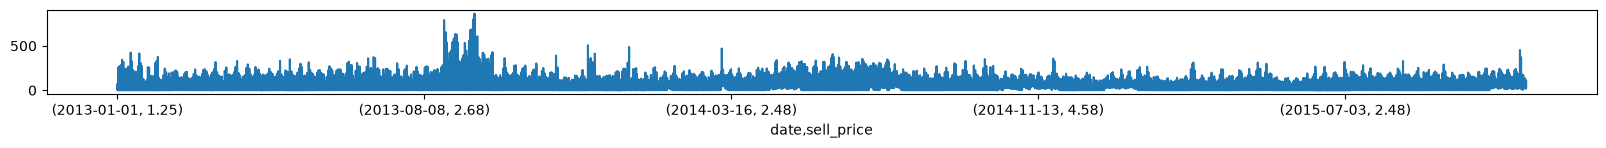